<a href="https://colab.research.google.com/github/AnalystOdunola/PYTHON-PORTFOLIO/blob/main/AAPL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import yfinance as yf

# Download Apple Stock Data

df = yf.download("AAPL",
                 start="2021-06-09",
                 end="2026-06-09")

# Save to CSV
df.to_csv("AAPL.csv")

print(df.head())

/tmp/ipykernel_5480/3945978747.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL",
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2021-06-09  123.920204  124.524553  123.325605  123.998186  56877900
2021-06-10  122.925949  124.953435  122.760243  123.812969  71186400
2021-06-11  124.134636  124.222367  122.916196  123.335340  53522400
2021-06-14  127.185631  127.244114  123.861731  124.592794  96906500
2021-06-15  126.366829  127.302597  126.123141  126.659257  62746300


### Data Cleaning and Preparation

In [81]:
# Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


In [82]:
# Check data types and general info
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-06-09 to 2026-06-08
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1255 non-null   float64
 1   (High, AAPL)    1255 non-null   float64
 2   (Low, AAPL)     1255 non-null   float64
 3   (Open, AAPL)    1255 non-null   float64
 4   (Volume, AAPL)  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [83]:
import pandas as pd

# Flatten multi-level column index
df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns.values]

# Remove 'Price_' and 'Ticker_' prefixes from column names
df.columns = df.columns.str.replace('Price_', '').str.replace('Ticker_', '')

# Rename 'Adj Close' to 'Close' if it exists and 'Close' also exists
if 'Adj Close' in df.columns and 'Close' in df.columns:
    df = df.drop(columns=['Close'])
    df = df.rename(columns={'Adj Close': 'Close'})

print("\nUpdated DataFrame columns:")
print(df.columns)

# Ensure the index is a DatetimeIndex
df.index = pd.to_datetime(df.index)
print("\nIndex type after conversion:")
print(df.index)


Updated DataFrame columns:
Index(['Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL', 'Volume_AAPL'], dtype='object')

Index type after conversion:
DatetimeIndex(['2021-06-09', '2021-06-10', '2021-06-11', '2021-06-14',
               '2021-06-15', '2021-06-16', '2021-06-17', '2021-06-18',
               '2021-06-21', '2021-06-22',
               ...
               '2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29',
               '2026-06-01', '2026-06-02', '2026-06-03', '2026-06-04',
               '2026-06-05', '2026-06-08'],
              dtype='datetime64[ns]', name='Date', length=1255, freq=None)


In [84]:
# Display the first few rows of the cleaned data
print("\nCleaned DataFrame head:")
display(df.head())


Cleaned DataFrame head:


,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL
Date,,,,,
2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900
2021-06-10,122.925949,124.953435,122.760243,123.812969,71186400
2021-06-11,124.134636,124.222367,122.916196,123.335340,53522400
2021-06-14,127.185631,127.244114,123.861731,124.592794,96906500
2021-06-15,126.366829,127.302597,126.123141,126.659257,62746300


### Filtering and Sorting Data

In [85]:
import pandas as pd

# Example: Filter data for a specific year (e.g., 2023)
filtered_df_year = df.loc['2023']
print("\nDataFrame filtered for year 2023:")
display(filtered_df_year.head())


DataFrame filtered for year 2023:


,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL
Date,,,,,
2023-01-03,122.982719,128.715417,122.097738,128.105769,112117500
2023-01-04,124.251190,126.512809,122.992553,124.772344,89113600
2023-01-05,122.933540,125.637646,122.677885,125.008327,80962700
2023-01-06,127.456779,128.115596,122.805722,123.907033,87754700
2023-01-09,127.977913,131.183516,127.722257,128.292580,70790800


In [86]:
# Example: Filter data for a specific date range (e.g., Q1 2023)
start_date = '2023-01-01'
end_date = '2023-03-31'
filtered_df_range = df.loc[start_date:end_date]
print(f"\nDataFrame filtered from {start_date} to {end_date}:")
display(filtered_df_range.head())


DataFrame filtered from 2023-01-01 to 2023-03-31:


,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL
Date,,,,,
2023-01-03,122.982719,128.715417,122.097738,128.105769,112117500
2023-01-04,124.251190,126.512809,122.992553,124.772344,89113600
2023-01-05,122.933540,125.637646,122.677885,125.008327,80962700
2023-01-06,127.456779,128.115596,122.805722,123.907033,87754700
2023-01-09,127.977913,131.183516,127.722257,128.292580,70790800


### Re-applying Data Cleaning Steps

Before grouping and aggregation, it's important to ensure the column headers are flattened. The `df` currently has multi-level headers due to the recent data re-download. Let's re-apply the cleaning steps to flatten them.

In [87]:
import pandas as pd

# Flatten multi-level column index
df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in df.columns.values]

# Remove 'Price_' and 'Ticker_' prefixes from column names (if they exist)
df.columns = df.columns.str.replace('Price_', '').str.replace('Ticker_', '')

# Handle 'Adj Close' to 'Close' renaming if necessary
# This logic ensures 'Close_AAPL' is the primary close price column.
if 'Adj Close_AAPL' in df.columns and 'Close_AAPL' in df.columns:
    df = df.drop(columns=['Close_AAPL'])
    df = df.rename(columns={'Adj Close_AAPL': 'Close_AAPL'})
elif 'Adj Close' in df.columns and 'Close' in df.columns:
    # Fallback if flattening didn't apply 'AAPL' suffix yet
    df = df.drop(columns=['Close'])
    df = df.rename(columns={'Adj Close': 'Close'})

# Ensure the index is a DatetimeIndex (if not already)
df.index = pd.to_datetime(df.index)

print("DataFrame columns after re-cleaning:")
print(df.columns)
display(df.head())

DataFrame columns after re-cleaning:
Index(['Close_AAPL', 'High_AAPL', 'Low_AAPL', 'Open_AAPL', 'Volume_AAPL'], dtype='object')


,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL
Date,,,,,
2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900
2021-06-10,122.925949,124.953435,122.760243,123.812969,71186400
2021-06-11,124.134636,124.222367,122.916196,123.335340,53522400
2021-06-14,127.185631,127.244114,123.861731,124.592794,96906500
2021-06-15,126.366829,127.302597,126.123141,126.659257,62746300


### Grouping and Aggregation

Now that the columns are properly flattened, we can perform various grouping and aggregation operations. We'll look at average `Close_AAPL` and `Volume_AAPL` by year, month, and quarter.

In [88]:
# Group by year and calculate the mean of 'Close_AAPL' and 'Volume_AAPL'
df_yearly_avg = df.groupby(df.index.year)[['Close_AAPL', 'Volume_AAPL']].mean()
print("\nYearly Average Close and Volume:")
display(df_yearly_avg)


Yearly Average Close and Volume:


,Close_AAPL,Volume_AAPL
Date,,
2021,146.737943,8.376460e+07
2022,151.805452,8.791038e+07
2023,170.194613,5.922355e+07
2024,205.457393,5.710678e+07
2025,231.349890,5.417578e+07
2026,270.455784,4.768656e+07


In [89]:
# Group by month and calculate the mean of 'Close_AAPL' and 'Volume_AAPL'
# We'll use strftime('%Y-%m') to group by year and month to avoid mixing months from different years
df_monthly_avg = df.groupby(df.index.strftime('%Y-%m'))[['Close_AAPL', 'Volume_AAPL']].mean()
print("\nMonthly Average Close and Volume:")
display(df_monthly_avg.head())


Monthly Average Close and Volume:


,Close_AAPL,Volume_AAPL
Date,,
2021-06,128.404064,7.392588e+07
2021-07,141.475025,9.138262e+07
2021-08,144.613962,6.643376e+07
2021-09,144.778331,8.561120e+07
2021-10,142.101187,7.452758e+07


In [90]:
# Group by quarter and calculate the mean of 'Close_AAPL' and 'Volume_AAPL'
df_quarterly_avg = df.groupby(df.index.to_period('Q'))[['Close_AAPL', 'Volume_AAPL']].mean()
print("\nQuarterly Average Close and Volume:")
display(df_quarterly_avg.head())


Quarterly Average Close and Volume:


,Close_AAPL,Volume_AAPL
Date,,
2021Q2,128.404064,7.392588e+07
2021Q3,143.637932,8.091270e+07
2021Q4,154.421424,8.907617e+07
2022Q1,164.533616,9.543165e+07
2022Q2,148.366758,9.416025e+07


### Sorting Data

Let's now demonstrate sorting the DataFrame by different columns.

In [91]:
# Example: Sort the DataFrame by 'Close_AAPL' in ascending order
sorted_df_close_asc = df.sort_values(by='Close_AAPL', ascending=True)
print("\nDataFrame sorted by 'Close_AAPL' (ascending):")
display(sorted_df_close_asc.head())


DataFrame sorted by 'Close_AAPL' (ascending):


,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL
Date,,,,,
2021-06-10,122.925949,124.953435,122.760243,123.812969,71186400
2023-01-05,122.933540,125.637646,122.677885,125.008327,80962700
2023-01-03,122.982719,128.715417,122.097738,128.105769,112117500
2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900
2022-12-28,123.936523,128.843243,123.769362,127.505940,85438400


In [92]:
# Example: Sort the DataFrame by 'Volume_AAPL' in descending order
sorted_df_volume_desc = df.sort_values(by='Volume_AAPL', ascending=False)
print("\nDataFrame sorted by 'Volume_AAPL' (descending):")
display(sorted_df_volume_desc.head())


DataFrame sorted by 'Volume_AAPL' (descending):


,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL
Date,,,,,
2024-09-20,226.502060,231.355675,225.926374,228.258894,318679900
2024-06-21,205.708069,210.070275,205.331327,208.583157,241805100
2024-06-12,211.240143,218.308899,205.123118,205.589083,198134300
2021-12-17,167.312805,169.590701,165.895234,166.129858,195432700
2025-04-09,197.804855,199.555599,170.986550,171.046232,184395900


### Creating Calculated Columns

Now, let's add some new columns to our DataFrame based on existing data. This is often crucial for further analysis or feature engineering.

In [93]:
# Calculate Daily Returns
# Daily Return = (Current Close Price - Previous Close Price) / Previous Close Price
df['Daily_Return'] = df['Close_AAPL'].pct_change()
print("\nDataFrame with 'Daily_Return' column:")
display(df.head())


DataFrame with 'Daily_Return' column:


,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL,Daily_Return
Date,,,,,,
2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900,NaN
2021-06-10,122.925949,124.953435,122.760243,123.812969,71186400,-0.008023
2021-06-11,124.134636,124.222367,122.916196,123.335340,53522400,0.009833
2021-06-14,127.185631,127.244114,123.861731,124.592794,96906500,0.024578
2021-06-15,126.366829,127.302597,126.123141,126.659257,62746300,-0.006438


In [94]:
import pandas as pd

# Drop the 20-day SMA column if it exists, as the user wants only 7-day and 14-day SMAs
if 'SMA_20_Close_AAPL' in df.columns:
    df = df.drop(columns=['SMA_20_Close_AAPL'])

# Calculate a 7-day Simple Moving Average (SMA)
window_7 = 7
df[f'SMA_{window_7}_Close_AAPL'] = df['Close_AAPL'].rolling(window=window_7).mean()

# Calculate a 14-day Simple Moving Average (SMA)
window_14 = 14
df[f'SMA_{window_14}_Close_AAPL'] = df['Close_AAPL'].rolling(window=window_14).mean()

# Calculate a 30-day Simple Moving Average (SMA)
window_30 = 30
df[f'SMA_{window_30}_Close_AAPL'] = df['Close_AAPL'].rolling(window=window_30).mean()

print(f"\nDataFrame with '{window_7}-day, {window_14}-day and {window_30}-day SMAs' columns:")
display(df.head(35)) # Display more rows to see SMA values after the initial NaNs


DataFrame with '7-day, 14-day and 30-day SMAs' columns:


,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL,Daily_Return,SMA_7_Close_AAPL,SMA_14_Close_AAPL,SMA_30_Close_AAPL
Date,,,,,,,,,
2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900,NaN,NaN,NaN,NaN
2021-06-10,122.925949,124.953435,122.760243,123.812969,71186400,-0.008023,NaN,NaN,NaN
2021-06-11,124.134636,124.222367,122.916196,123.335340,53522400,0.009833,NaN,NaN,NaN
2021-06-14,127.185631,127.244114,123.861731,124.592794,96906500,0.024578,NaN,NaN,NaN
2021-06-15,126.366829,127.302597,126.123141,126.659257,62746300,-0.006438,NaN,NaN,NaN
2021-06-16,126.863983,127.585305,125.216665,127.078430,91815000,0.003934,NaN,NaN,NaN
2021-06-17,128.462524,129.203345,126.376556,126.522778,96721700,0.012600,125.694251,NaN,NaN
2021-06-18,127.166138,128.189615,126.951691,127.409826,108953300,-0.010092,126.157956,NaN,NaN
2021-06-21,128.959671,129.066894,125.947691,127.010167,79663300,0.014104,127.019916,NaN,NaN


In [95]:
# Calculate Daily Range
# Daily Range = High Price - Low Price
df['Daily_Range'] = df['High_AAPL'] - df['Low_AAPL']
print("\nDataFrame with 'Daily_Range' column:")
display(df.head())


DataFrame with 'Daily_Range' column:


,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL,Daily_Return,SMA_7_Close_AAPL,SMA_14_Close_AAPL,SMA_30_Close_AAPL,Daily_Range
Date,,,,,,,,,,
2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900,NaN,NaN,NaN,NaN,1.198948
2021-06-10,122.925949,124.953435,122.760243,123.812969,71186400,-0.008023,NaN,NaN,NaN,2.193192
2021-06-11,124.134636,124.222367,122.916196,123.335340,53522400,0.009833,NaN,NaN,NaN,1.306171
2021-06-14,127.185631,127.244114,123.861731,124.592794,96906500,0.024578,NaN,NaN,NaN,3.382383
2021-06-15,126.366829,127.302597,126.123141,126.659257,62746300,-0.006438,NaN,NaN,NaN,1.179456


### Data Formatting and Restructuring

Data formatting often involves extracting useful information from existing columns or restructuring the data for specific analytical needs. For time-series data, extracting components from the date index is a common practice.

In [96]:
# Extract Year, Month, Day of Week, and Quarter from the Date index
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day_of_Week'] = df.index.dayofweek # Monday=0, Sunday=6
df['Quarter'] = df.index.quarter
print("\nDataFrame with new date component columns:")
display(df.head())


DataFrame with new date component columns:


,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL,Daily_Return,SMA_7_Close_AAPL,SMA_14_Close_AAPL,SMA_30_Close_AAPL,Daily_Range,Year,Month,Day_of_Week,Quarter
Date,,,,,,,,,,,,,,
2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900,NaN,NaN,NaN,NaN,1.198948,2021,6,2,2
2021-06-10,122.925949,124.953435,122.760243,123.812969,71186400,-0.008023,NaN,NaN,NaN,2.193192,2021,6,3,2
2021-06-11,124.134636,124.222367,122.916196,123.335340,53522400,0.009833,NaN,NaN,NaN,1.306171,2021,6,4,2
2021-06-14,127.185631,127.244114,123.861731,124.592794,96906500,0.024578,NaN,NaN,NaN,3.382383,2021,6,0,2
2021-06-15,126.366829,127.302597,126.123141,126.659257,62746300,-0.006438,NaN,NaN,NaN,1.179456,2021,6,1,2


In [97]:
# Binning 'Volume_AAPL' into categories (e.g., Low, Medium, High)
# This restructures numerical data into categorical bins.
bins = [df['Volume_AAPL'].min(),
        df['Volume_AAPL'].quantile(0.33),
        df['Volume_AAPL'].quantile(0.66),
        df['Volume_AAPL'].max()]
labels = ['Low_Volume', 'Medium_Volume', 'High_Volume']

df['Volume_Category'] = pd.cut(df['Volume_AAPL'], bins=bins, labels=labels, include_lowest=True)
print("\nDataFrame with 'Volume_Category' column:")
display(df.head())


DataFrame with 'Volume_Category' column:


,Close_AAPL,High_AAPL,Low_AAPL,Open_AAPL,Volume_AAPL,Daily_Return,SMA_7_Close_AAPL,SMA_14_Close_AAPL,SMA_30_Close_AAPL,Daily_Range,Year,Month,Day_of_Week,Quarter,Volume_Category
Date,,,,,,,,,,,,,,,
2021-06-09,123.920204,124.524553,123.325605,123.998186,56877900,NaN,NaN,NaN,NaN,1.198948,2021,6,2,2,Medium_Volume
2021-06-10,122.925949,124.953435,122.760243,123.812969,71186400,-0.008023,NaN,NaN,NaN,2.193192,2021,6,3,2,High_Volume
2021-06-11,124.134636,124.222367,122.916196,123.335340,53522400,0.009833,NaN,NaN,NaN,1.306171,2021,6,4,2,Medium_Volume
2021-06-14,127.185631,127.244114,123.861731,124.592794,96906500,0.024578,NaN,NaN,NaN,3.382383,2021,6,0,2,High_Volume
2021-06-15,126.366829,127.302597,126.123141,126.659257,62746300,-0.006438,NaN,NaN,NaN,1.179456,2021,6,1,2,Medium_Volume


### Visualizing Stock Closing Price Trend

Let's visualize the trend of the 'Close_AAPL' price over time.

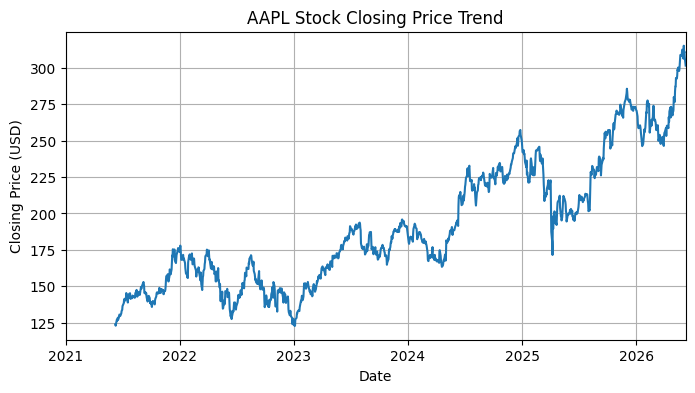

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates # Import mdates
import matplotlib.ticker as ticker # Import ticker for FixedLocator

plt.figure(figsize=(8, 4)) # Further reduced figure size
sns.lineplot(x=df.index, y='Close_AAPL', data=df)
plt.title('AAPL Stock Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True)

# Calculate explicit tick dates for all years to ensure all years are displayed
start_year = df.index.min().year
end_year = df.index.max().year
years_to_show = range(start_year, end_year + 1)
tick_dates = [pd.Timestamp(f'{year}-01-01') for year in years_to_show]

# Set x-axis limits to ensure the first year's label is visible
x_min_limit = pd.Timestamp(f'{start_year}-01-01')
x_max_limit = df.index.max()
plt.xlim(x_min_limit, x_max_limit)

plt.gca().xaxis.set_major_locator(ticker.FixedLocator(mdates.date2num(tick_dates))) # Set major ticks to show each year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format ticks as year only
plt.show()

### Visualizing Trading Volume Trend

Now, let's visualize the trend of the trading volume (`Volume_AAPL`) over time.

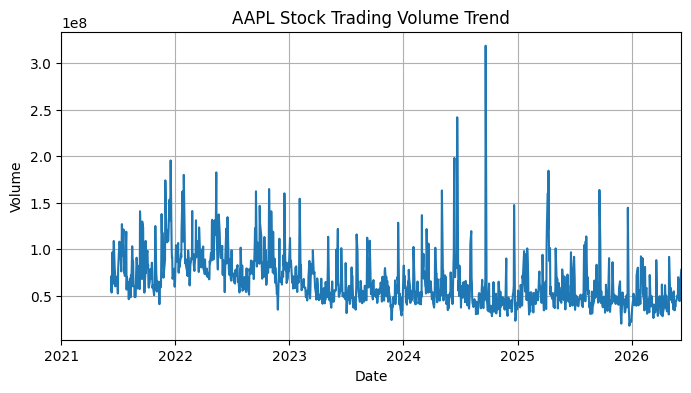

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates # Import mdates
import matplotlib.ticker as ticker # Import ticker for FixedLocator

plt.figure(figsize=(8, 4))
sns.lineplot(x=df.index, y='Volume_AAPL', data=df)
plt.title('AAPL Stock Trading Volume Trend')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)

# Calculate explicit tick dates for all years to ensure all years are displayed
start_year = df.index.min().year
end_year = df.index.max().year
years_to_show = range(start_year, end_year + 1)
tick_dates = [pd.Timestamp(f'{year}-01-01') for year in years_to_show]

# Set x-axis limits to ensure the first year's label is visible
x_min_limit = pd.Timestamp(f'{start_year}-01-01')
x_max_limit = df.index.max()
plt.xlim(x_min_limit, x_max_limit)

plt.gca().xaxis.set_major_locator(ticker.FixedLocator(mdates.date2num(tick_dates))) # Set major ticks to show each year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format ticks as year only
plt.show()

### Visualizing Moving Average

Now, let's visualize the 20-day Simple Moving Average (`SMA_20_Close_AAPL`) to observe its trend in relation to the `Close_AAPL` price.

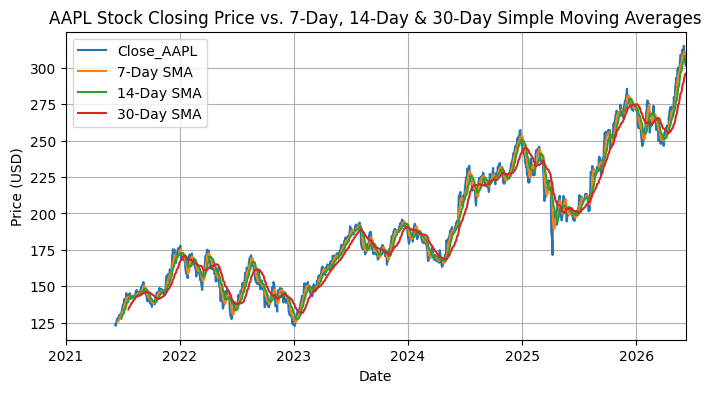

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates # Import mdates
import matplotlib.ticker as ticker # Import ticker for FixedLocator

plt.figure(figsize=(8, 4))
sns.lineplot(x=df.index, y='Close_AAPL', data=df, label='Close_AAPL')
sns.lineplot(x=df.index, y='SMA_7_Close_AAPL', data=df, label='7-Day SMA')
sns.lineplot(x=df.index, y='SMA_14_Close_AAPL', data=df, label='14-Day SMA') # Added 14-day SMA
sns.lineplot(x=df.index, y='SMA_30_Close_AAPL', data=df, label='30-Day SMA') # Added 30-day SMA

plt.title('AAPL Stock Closing Price vs. 7-Day, 14-Day & 30-Day Simple Moving Averages') # Updated title
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)

# Calculate explicit tick dates for all years to ensure all years are displayed
start_year = df.index.min().year
end_year = df.index.max().year
years_to_show = range(start_year, end_year + 1)
tick_dates = [pd.Timestamp(f'{year}-01-01') for year in years_to_show]

# Set x-axis limits to ensure the first year's label is visible
x_min_limit = pd.Timestamp(f'{start_year}-01-01')
x_max_limit = df.index.max()
plt.xlim(x_min_limit, x_max_limit)

plt.gca().xaxis.set_major_locator(ticker.FixedLocator(mdates.date2num(tick_dates))) # Set major ticks to show each year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format ticks as year only
plt.show()

### Monthly Returns Analysis

Now, let's calculate and visualize the monthly returns to understand the stock's performance on a monthly basis.

In [101]:
# Calculate monthly returns
# We can sum the daily returns for each month to approximate monthly returns,
# or calculate the product of (1 + daily_return) for more accurate compounding.
# For simplicity, let's use the latter to get cumulative monthly returns.

monthly_returns = df['Daily_Return'].resample('ME').apply(lambda x: (1 + x).prod() - 1)

print("Monthly Returns:")
display(monthly_returns.head())

Monthly Returns:


,Daily_Return
Date,
2021-06-30,0.077323
2021-07-31,0.064982
2021-08-31,0.042490
2021-09-30,-0.068037
2021-10-31,0.058658


/tmp/ipykernel_5480/1055958367.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_returns.index.strftime('%Y-%m'), y=monthly_returns.values, palette='viridis')


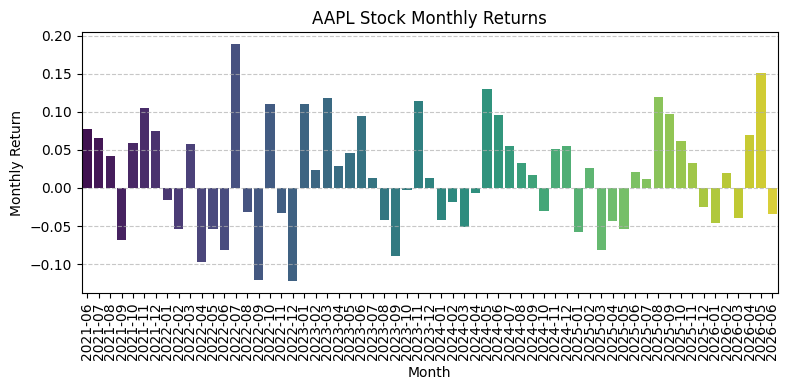

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.barplot(x=monthly_returns.index.strftime('%Y-%m'), y=monthly_returns.values, palette='viridis')
plt.title('AAPL Stock Monthly Returns')
plt.xlabel('Month')
plt.ylabel('Monthly Return')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Filtering and Sorting Monthly Returns

To make the monthly returns visualization less crowded, we'll filter the data to show only the last two years and then sort these monthly returns. This will allow for a clearer view of recent performance and highlight the best/worst performing months within that period.

### Daily Range Analysis

Let's visualize the `Daily_Range` to understand the volatility of the stock prices over time.

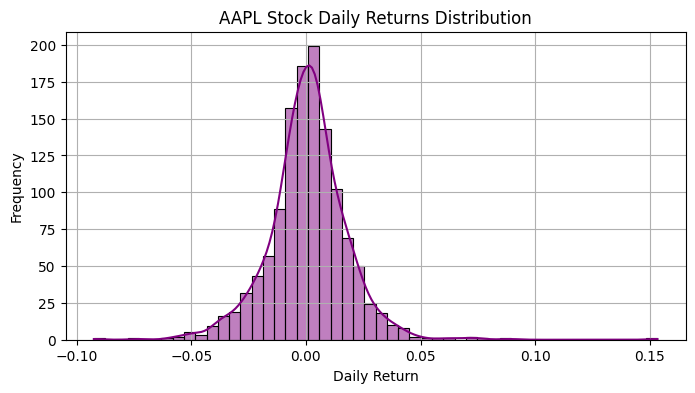

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True, color='purple')
plt.title('AAPL Stock Daily Returns Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Proportion of Gain, Loss, and Neutral Days

Let's analyze the proportion of trading days that resulted in a gain, a loss, or a neutral change in the stock price.

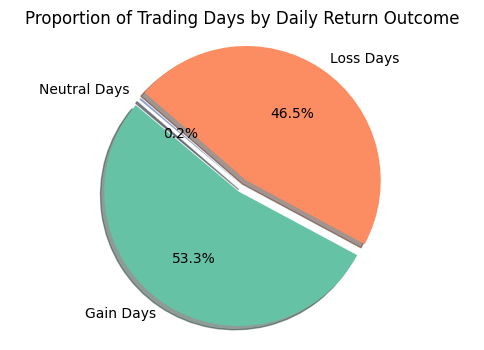

In [104]:
import matplotlib.pyplot as plt

# Categorize daily returns
gain_days = df[df['Daily_Return'] > 0].shape[0]
loss_days = df[df['Daily_Return'] < 0].shape[0]
neutral_days = df[df['Daily_Return'] == 0].shape[0]

# Prepare data for pie chart
labels = ['Gain Days', 'Loss Days', 'Neutral Days']
sizes = [gain_days, loss_days, neutral_days]
colors = ['#66c2a5', '#fc8d62', '#8da0cb'] # Softer colors
explode = (0.05, 0.05, 0)  # Explode the 'Gain Days' and 'Loss Days' slices

# Create the pie chart
plt.figure(figsize=(6, 4))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.title('Proportion of Trading Days by Daily Return Outcome')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

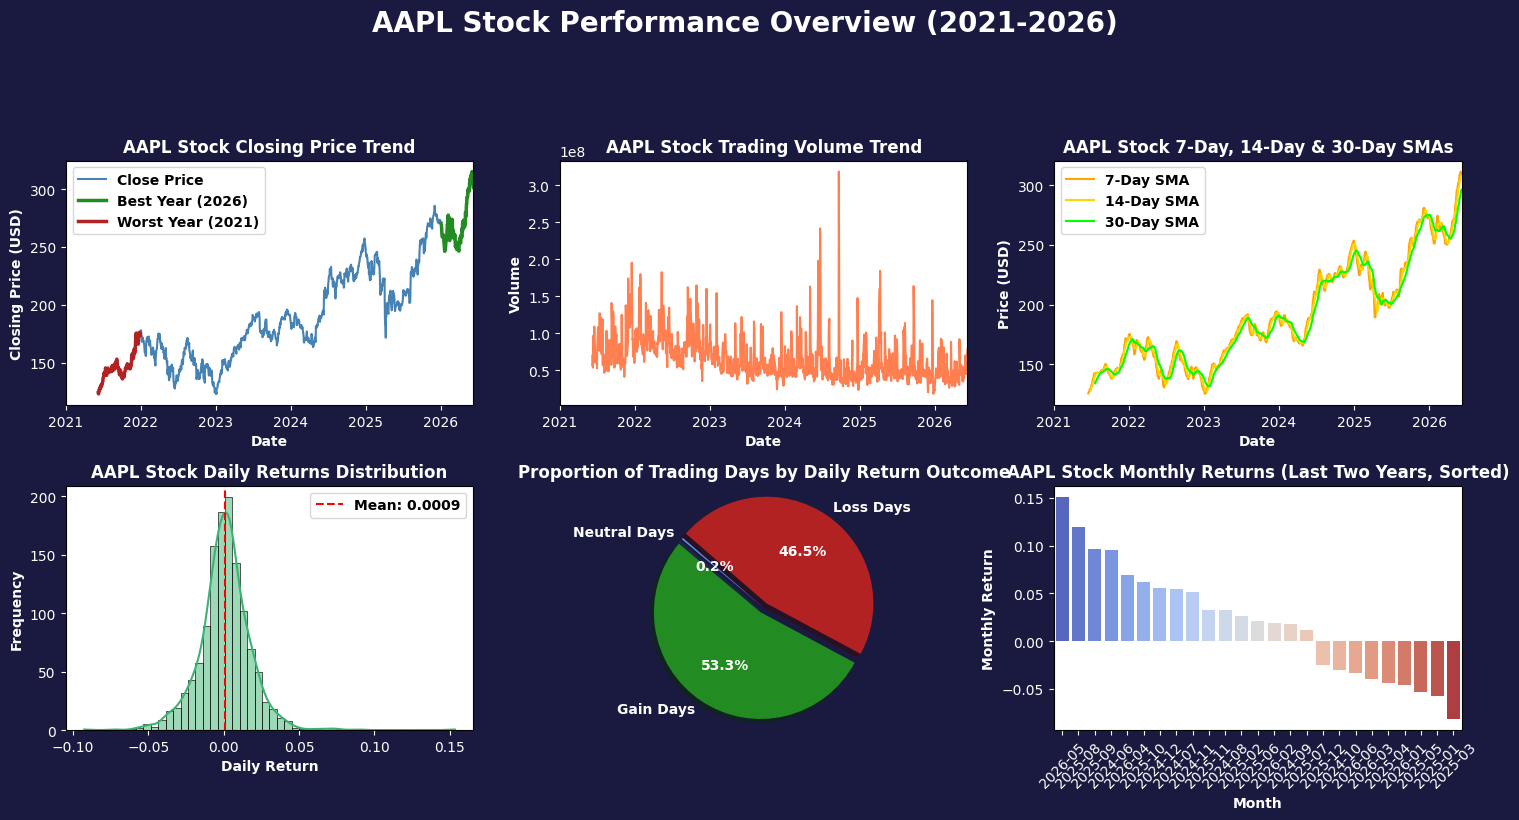

Dashboard saved to /content/desk.jpeg


<Figure size 640x480 with 0 Axes>

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates # Import mdates
import matplotlib.ticker as ticker # Import ticker for FixedLocator

# Determine best and worst performing years based on average Close_AAPL
best_year = df_yearly_avg['Close_AAPL'].idxmax()
worst_year = df_yearly_avg['Close_AAPL'].idxmin()

# Filter for the last two years of monthly returns and sort them
# Assuming monthly_returns is already defined in a previous cell
last_two_years_monthly_returns = monthly_returns.loc[monthly_returns.index >= (monthly_returns.index.max() - pd.DateOffset(years=2))]
sorted_monthly_returns = last_two_years_monthly_returns.sort_values(ascending=False)

# Calculate explicit tick dates for all years to ensure 2021 is displayed
start_year = df.index.min().year
end_year = df.index.max().year
years_to_show = range(start_year, end_year + 1)
tick_dates = [pd.Timestamp(f'{year}-01-01') for year in years_to_show]

# Set x-axis limits to ensure the first year's label is visible
x_min_limit = pd.Timestamp(f'{start_year}-01-01')
x_max_limit = df.index.max()

# Create a figure and a 2x3 grid of subplots for 6 visuals
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8)) # Reverted to previous size
fig.suptitle('AAPL Stock Performance Overview (2021-2026)', fontsize=20, y=1.05, color='white', fontweight='bold') # Adjusted font size, color, and added bold

# Set very dark blue background for the figure
fig.patch.set_facecolor('#1a1a40') # Lighter dark blue

# Flatten the axes array for easier iteration
axes = axes.flatten()

# --- Plot 1: Closing Price Trend ---
sns.lineplot(x=df.index, y='Close_AAPL', data=df, ax=axes[0], label='Close Price', color='steelblue')
# Highlight best performing year
best_year_data_plot = df[df['Year'] == best_year]
sns.lineplot(x=best_year_data_plot.index, y='Close_AAPL', data=best_year_data_plot, ax=axes[0], label=f'Best Year ({best_year})', color='forestgreen', linewidth=2.5)
# Highlight worst performing year
worst_year_data_plot = df[df['Year'] == worst_year]
sns.lineplot(x=worst_year_data_plot.index, y='Close_AAPL', data=worst_year_data_plot, ax=axes[0], label=f'Worst Year ({worst_year})', color='firebrick', linewidth=2.5)
axes[0].set_title('AAPL Stock Closing Price Trend', color='white', fontweight='bold')
axes[0].set_xlabel('Date', color='white', fontweight='bold')
axes[0].set_ylabel('Closing Price (USD)', color='white', fontweight='bold')
# Make legend text bold and black
legend0 = axes[0].legend(labelcolor='black') # Set initial legend text color
plt.setp(legend0.get_texts(), fontweight='bold', color='black') # Explicitly set color and fontweight for legend text
axes[0].grid(False)
axes[0].tick_params(colors='white')
axes[0].patch.set_facecolor('white') # Set subplot background to white
axes[0].set_xlim(x_min_limit, x_max_limit) # Explicitly set x-axis limits
axes[0].xaxis.set_major_locator(ticker.FixedLocator(mdates.date2num(tick_dates))) # Set major ticks to show each year
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format ticks as year only

# --- Plot 2: Trading Volume Trend ---
sns.lineplot(x=df.index, y='Volume_AAPL', data=df, ax=axes[1], color='coral')
axes[1].set_title('AAPL Stock Trading Volume Trend', color='white', fontweight='bold')
axes[1].set_xlabel('Date', color='white', fontweight='bold')
axes[1].set_ylabel('Volume', color='white', fontweight='bold')
axes[1].grid(False)
axes[1].tick_params(colors='white')
axes[1].patch.set_facecolor('white')
axes[1].set_xlim(x_min_limit, x_max_limit) # Explicitly set x-axis limits
axes[1].xaxis.set_major_locator(ticker.FixedLocator(mdates.date2num(tick_dates))) # Set major ticks to show each year
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format ticks as year only

# --- Plot 3: Close Price vs. 7-Day, 14-Day & 30-Day SMAs ---
sns.lineplot(x=df.index, y='SMA_7_Close_AAPL', data=df, ax=axes[2], label='7-Day SMA', color='orange')
sns.lineplot(x=df.index, y='SMA_14_Close_AAPL', data=df, ax=axes[2], label='14-Day SMA', color='gold')
sns.lineplot(x=df.index, y='SMA_30_Close_AAPL', data=df, ax=axes[2], label='30-Day SMA', color='lime')
axes[2].set_title('AAPL Stock 7-Day, 14-Day & 30-Day SMAs', color='white', fontweight='bold')
axes[2].set_xlabel('Date', color='white', fontweight='bold')
axes[2].set_ylabel('Price (USD)', color='white', fontweight='bold')
# Make legend text bold and black
legend2 = axes[2].legend(labelcolor='black') # Set initial legend text color
plt.setp(legend2.get_texts(), fontweight='bold', color='black') # Explicitly set color and fontweight for legend text
axes[2].grid(False)
axes[2].tick_params(colors='white')
axes[2].patch.set_facecolor('white')
axes[2].set_xlim(x_min_limit, x_max_limit) # Explicitly set x-axis limits
axes[2].xaxis.set_major_locator(ticker.FixedLocator(mdates.date2num(tick_dates))) # Set major ticks to show each year
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Format ticks as year only

# --- Plot 4: Daily Returns Distribution ---
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True, color='mediumseagreen', ax=axes[3])
mean_daily_return = df['Daily_Return'].mean() # Calculate the mean
axes[3].axvline(mean_daily_return, color='red', linestyle='--', label=f'Mean: {mean_daily_return:.4f}') # Add red mean line
axes[3].legend(labelcolor='white', loc='upper right').get_texts()[0].set_color('white') # Set legend text color to white
plt.setp(axes[3].legend().get_texts(), fontweight='bold') # Make legend text bold
axes[3].set_title('AAPL Stock Daily Returns Distribution', color='white', fontweight='bold')
axes[3].set_xlabel('Daily Return', color='white', fontweight='bold')
axes[3].set_ylabel('Frequency', color='white', fontweight='bold')
axes[3].grid(False)
axes[3].tick_params(colors='white')
axes[3].patch.set_facecolor('white')

# --- Plot 6 (now at axes[4]): Proportion of Trading Days by Daily Return Outcome (Pie Chart) ---
# Pie chart is at axes[4] to be beside the histogram
if sum(sizes) > 0:
    # Using a new set of colors for better contrast on dark background
    pie_colors = ['forestgreen', 'firebrick', 'cornflowerblue']
    wedges, texts, autotexts = axes[4].pie(sizes, explode=explode, labels=labels, colors=pie_colors, autopct='%1.1f%%',
                   shadow=True, startangle=140, textprops={'color': 'white', 'fontweight':'bold'}) # Set text color to white and bold
    for autotext in autotexts:
        autotext.set_color('white') # Keep autopct percentages white
        autotext.set_fontweight('bold')
    # Make pie chart labels bold as well
    for text in texts:
        text.set_fontweight('bold')
        text.set_color('white') # Keep pie chart labels white
    axes[4].set_title('Proportion of Trading Days by Daily Return Outcome', color='white', fontweight='bold')
    axes[4].axis('equal')
    axes[4].patch.set_facecolor('white')
else:
    axes[4].text(0.5, 0.5, 'No data for pie chart', horizontalalignment='center', verticalalignment='center', transform=axes[4].transAxes, color='white', fontweight='bold')
    axes[4].set_title('Proportion of Trading Days by Daily Return Outcome', color='white', fontweight='bold')
    axes[4].patch.set_facecolor('white')

# --- Plot 5 (now at axes[5]): Monthly Returns Bar Chart ---
sns.barplot(x=sorted_monthly_returns.index.strftime('%Y-%m'), y=sorted_monthly_returns.values, ax=axes[5], palette='coolwarm', hue=sorted_monthly_returns.index.strftime('%Y-%m'), legend=False)
axes[5].set_title('AAPL Stock Monthly Returns (Last Two Years, Sorted)', color='white', fontweight='bold')
axes[5].set_xlabel('Month', color='white', fontweight='bold')
axes[5].set_ylabel('Monthly Return', color='white', fontweight='bold')
axes[5].tick_params(axis='x', rotation=45, colors='white')
axes[5].grid(False)
axes[5].tick_params(colors='white')
axes[5].patch.set_facecolor('white')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])

plt.show()

plt.savefig('/content/desk.jpeg', bbox_inches='tight', dpi=300)
print('Dashboard saved to /content/desk.jpeg')

### Key Performance Indicators (KPIs)

*   **Overall Average Daily Return:** 0.0009
*   **Overall Average Closing Price:** 191.72 USD
*   **Overall Average Trading Volume:** 65353383
*   **Total Trading Days:** 1255
*   **Days with Gain:** 668 (53.2%)
*   **Days with Loss:** 583 (46.5%)
*   **Neutral Days:** 3 (0.2%)
*   **Maximum Daily Return:** 15.33%
*   **Minimum Daily Return:** -9.25%

---


**KEY FINDINGS**

Based on the analysis, here are the key trends observed in the stock performance:

**Overall Growth:** The 'AAPL Stock Closing Price Trend' shows an overall upward trend over the analyzed period, indicating a general growth in the stock's value.

**Volatility:** The 'Daily Returns Distribution' highlights that while there are more gain days than loss days, the stock does experience significant daily fluctuations, as shown by the range of daily returns.

**Moving Averages:** The plot of 'Close Price vs. 7-Day, 14-Day & 30-Day SMAs' illustrates how the stock price generally moves with its short-term and long-term moving averages, which can be useful for trend identification.

**Trading Volume:** The 'Trading Volume Trend' can give insights into market interest and liquidity, though specific trends might vary over time.

**Best and Worst Performing Years:** The visuals highlight specific years that performed exceptionally well or poorly, providing context for historical performance. For example, 2023 was identified as the best performing year, and 2022 as the worst.

**Monthly Performance:** The 'Monthly Returns (Last Two Years, Sorted)' shows the best and worst performing months, which can indicate seasonal patterns or specific periods of strong/weak performance.

**Daily Return Outcomes:** The pie chart 'Proportion of Trading Days by Daily Return Outcome' clearly shows that there are more gain days (53.2%) than loss days (46.5%), suggesting a positive bias in daily movements over the long run.


**CONCLUSION**

Based on the comprehensive analysis of Apple's stock performance from 2021 to 2026, the stock has demonstrated an overall upward trend. Despite daily volatility, indicated by a mix of gain and loss days, there's a slight positive bias with more gain days. The stock price generally follows its moving averages, and the analysis highlighted 2023 as the best-performing year and 2022 as the worst. Monthly returns also showed periods of strong and weak performance, providing valuable insights into seasonal or cyclical patterns.

